In [1]:
# Environment setup
# Install required packages for Google Colab
!pip install pandas numpy scikit-learn torch matplotlib seaborn openpyxl beautifulsoup4 lxml urlextract phonenumbers

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing libraries
from bs4 import BeautifulSoup
from urlextract import URLExtract
import phonenumbers

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Load the dataset
dataset_path = '/content/labeled_CEAS_08_preprocessed_shuffled.xlsx'
df = pd.read_excel(dataset_path)

# Display basic information
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape: (38951, 8)

Data types:
id           int64
sender      object
receiver    object
date        object
subject     object
body        object
label        int64
urls         int64
dtype: object

Missing values:
id            0
sender        0
receiver    460
date          0
subject      30
body          0
label         0
urls          0
dtype: int64

Label distribution:
label
1    21799
0    17152
Name: count, dtype: int64


In [6]:
### DATA PREPROCESSING

# Initialize extractors (done once for efficiency)
url_extractor = URLExtract()

# Select features from the dataset
features_cols = ['sender', 'subject', 'body']
target_col = 'label'

# Extract features and target
X = df[features_cols].copy()
y = df[target_col].copy()

# Handle missing values by replacing them with empty strings
for col in features_cols:
    X[col] = X[col].fillna('').astype(str)

# Text preprocessing function using libraries
def preprocess_text(text):

    # Remove HTML tags using BeautifulSoup
    soup = BeautifulSoup(text, 'lxml')
    text = soup.get_text(separator=' ')

    # Replace URLs using urlextract library
    urls = url_extractor.find_urls(text)
    for url in urls:
        text = text.replace(url, '<URL>')

    # Replace email addresses with special token
    text = re.sub(r'\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b', '<EMAIL>', text)

    # Replace phone numbers using phonenumbers library
    try:
        for match in phonenumbers.PhoneNumberMatcher(text, None):
            text = text.replace(match.raw_string, '<PHONE>')
    except:
        pass

    # Convert to lowercase
    text = text.lower()

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing to each text column
print("Preprocessing text data")
for col in features_cols:
    X[col] = X[col].apply(preprocess_text)

# Combine all text features into a single string
X['combined_text'] = X['sender'] + ' ' + X['subject'] + ' ' + X['body']

print("\nSample of combined text:")
print(X['combined_text'].head(3))
print("\nLabel distribution:")
print(y.value_counts())
print(f"\nPhishing rate: {y.mean():.2%}")

Preprocessing text data


/tmp/ipykernel_269/962742906.py:22: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  soup = BeautifulSoup(text, 'lxml')



Sample of combined text:
0    <email> re: [python-3000] the release gods are...
1    "david c. rankin" re: [opensuse] unstable syst...
2    godwin kidd make your intimate life more pleas...
Name: combined_text, dtype: object

Label distribution:
label
1    21799
0    17152
Name: count, dtype: int64

Phishing rate: 55.97%


In [7]:
# Split the dataset into train (70%), validation (15%), and test (15%)

# Split test set (15%)
X_rest, X_test, y_rest, y_test = train_test_split(
    X['combined_text'], y,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y # Ensures the split dataset follows the same label distribution as the original dataset
)

# Split train (70%) and validation (15%) from the remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest,
    test_size=0.15/0.85, # Get 15% of the original dataset
    random_state=RANDOM_SEED,
    stratify=y_rest
)

print("Dataset splits:")
print(f"Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"Train phishing rate: {y_train.mean():.2%}")
print(f"\nValidation label distribution:\n{y_val.value_counts()}")
print(f"Validation phishing rate: {y_val.mean():.2%}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")
print(f"Test phishing rate: {y_test.mean():.2%}")

Dataset splits:
Train set: 27265 samples (70.0%)
Validation set: 5843 samples (15.0%)
Test set: 5843 samples (15.0%)

Train label distribution:
label
1    15259
0    12006
Name: count, dtype: int64
Train phishing rate: 55.97%

Validation label distribution:
label
1    3270
0    2573
Name: count, dtype: int64
Validation phishing rate: 55.96%

Test label distribution:
label
1    3270
0    2573
Name: count, dtype: int64
Test phishing rate: 55.96%


In [8]:
### BASELINE MODEL
# Random predictions following the training data distribution

class BaselineModel:
    """
    Baseline model that randomly assigns labels based on training data distribution.
    If 60% of training data is label 0, this model predicts 0 with 60% probability.
    """
    def __init__(self):
        self.phishing_rate = None

    def fit(self, y_train):
        self.phishing_rate = y_train.mean()
        print(f"The data phishing rate is: {self.phishing_rate:.2%}")

    def predict(self, n_samples):
        # Use random.choice with probabilities based on training distribution
        predictions = np.random.choice(
            [0, 1],
            size=n_samples,
            p=[1 - self.phishing_rate, self.phishing_rate]
        )
        return predictions

# Train baseline model
baseline_model = BaselineModel()
baseline_model.fit(y_train)

# Generate predictions for validation and test sets
baseline_val_pred = baseline_model.predict(len(y_val))
baseline_test_pred = baseline_model.predict(len(y_test))

print(f"\nBaseline predictions - Validation set phishing rate: {baseline_val_pred.mean():.2%}")
print(f"Baseline predictions - Test set phishing rate: {baseline_test_pred.mean():.2%}")

The data phishing rate is: 55.97%

Baseline predictions - Validation set phishing rate: 55.23%
Baseline predictions - Test set phishing rate: 55.57%


In [9]:
# TF-IDF vectorization for FNN training
# Tokenization is handled by TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

# Fit vectorizer on training data and transform all sets
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_val_tfidf = vectorizer.transform(X_val).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features: {X_train_tfidf.shape[1]}")

TF-IDF feature shape: (27265, 5000)
Number of features: 5000


In [11]:
### FNN

# Build the FNN model
class FNN(nn.Module):
    def __init__(self, input_dim):
        super(FNN, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 64)
        self.dropout3 = nn.Dropout(0.5)
        self.output_layer = nn.Linear(64, 1)

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.sigmoid(self.output_layer(x))
        return x

# Create the model
input_dim = X_train_tfidf.shape[1]
fnn_model = FNN(input_dim).to(device)

# Display model architecture
print("FNN Model Architecture:")
print(fnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in fnn_model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in fnn_model.parameters() if p.requires_grad)}")

FNN Model Architecture:
FNN(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Total parameters: 1321473
Trainable parameters: 1321473


In [12]:
# Train the FNN model
print("Training FNN model...")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_tfidf).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
X_val_tensor = torch.FloatTensor(X_val_tfidf).to(device)
y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1).to(device)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(fnn_model.parameters())

# Training loop with early stopping
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# History dictionary to store metrics
history = {
    'loss': [], 'val_loss': [],
    'accuracy': [], 'val_accuracy': [],
    'precision': [], 'val_precision': [],
    'recall': [], 'val_recall': []
}

for epoch in range(num_epochs):
    # Training phase
    fnn_model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = fnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)
        train_preds.extend((outputs > 0.5).cpu().numpy().flatten())
        train_targets.extend(batch_y.cpu().numpy().flatten())

    train_loss /= len(train_loader.dataset)
    train_acc = accuracy_score(train_targets, train_preds)
    train_prec = precision_score(train_targets, train_preds, zero_division=0)
    train_rec = recall_score(train_targets, train_preds, zero_division=0)

    # Validation phase
    fnn_model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = fnn_model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            val_preds.extend((outputs > 0.5).cpu().numpy().flatten())
            val_targets.extend(batch_y.cpu().numpy().flatten())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_targets, val_preds)
    val_prec = precision_score(val_targets, val_preds, zero_division=0)
    val_rec = recall_score(val_targets, val_preds, zero_division=0)

    # Store metrics
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    history['precision'].append(train_prec)
    history['val_precision'].append(val_prec)
    history['recall'].append(train_rec)
    history['val_recall'].append(val_rec)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = fnn_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after epoch {epoch+1}")
            # Restore best model
            fnn_model.load_state_dict(best_model_state)
            break

print("\nTraining complete!")

Training FNN model...
Epoch 1/50 - Loss: 0.0644 - Acc: 0.9777 - Val Loss: 0.0224 - Val Acc: 0.9942
Epoch 2/50 - Loss: 0.0107 - Acc: 0.9974 - Val Loss: 0.0228 - Val Acc: 0.9933
Epoch 3/50 - Loss: 0.0044 - Acc: 0.9989 - Val Loss: 0.0290 - Val Acc: 0.9935
Epoch 4/50 - Loss: 0.0027 - Acc: 0.9994 - Val Loss: 0.0393 - Val Acc: 0.9938
Epoch 5/50 - Loss: 0.0011 - Acc: 0.9997 - Val Loss: 0.0563 - Val Acc: 0.9935
Epoch 6/50 - Loss: 0.0008 - Acc: 0.9999 - Val Loss: 0.0753 - Val Acc: 0.9937

Early stopping triggered after epoch 6

Training complete!


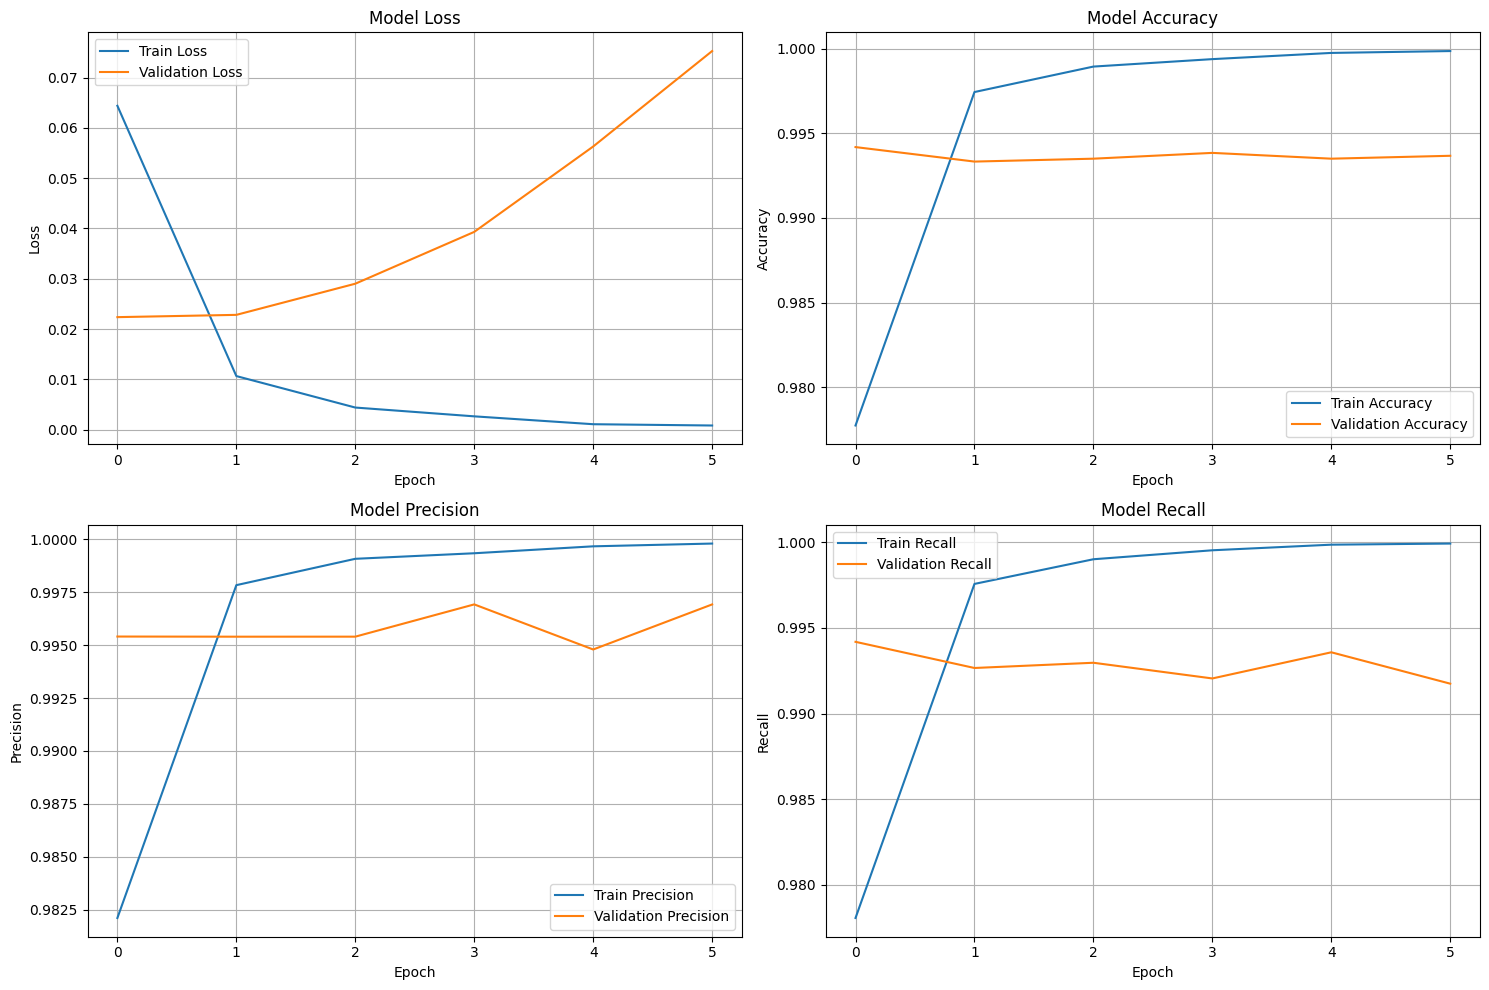

In [13]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot loss
axes[0, 0].plot(history['loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot accuracy
axes[0, 1].plot(history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot precision
axes[1, 0].plot(history['precision'], label='Train Precision')
axes[1, 0].plot(history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot recall
axes[1, 1].plot(history['recall'], label='Train Recall')
axes[1, 1].plot(history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Get predictions from FNN model
fnn_model.eval()

with torch.no_grad():
    # Validation predictions
    X_val_tensor = torch.FloatTensor(X_val_tfidf).to(device)
    fnn_val_pred_proba = fnn_model(X_val_tensor).cpu().numpy()
    fnn_val_pred = (fnn_val_pred_proba > 0.5).astype(int).flatten()

    # Test predictions
    X_test_tensor = torch.FloatTensor(X_test_tfidf).to(device)
    fnn_test_pred_proba = fnn_model(X_test_tensor).cpu().numpy()
    fnn_test_pred = (fnn_test_pred_proba > 0.5).astype(int).flatten()

In [16]:
### MODEL EVALUATION

def evaluate_model(y_test, y_pred, model_name, dataset_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{model_name} - {dataset_name}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Evaluate both models on validation set
print("\nVALIDATION SET EVALUATION")

baseline_val_results = evaluate_model(y_val, baseline_val_pred, "Baseline", "Validation")
fnn_val_results = evaluate_model(y_val, fnn_val_pred, "FNN", "Validation")

# Evaluate both models on test set
print("\nTEST SET EVALUATION")

baseline_test_results = evaluate_model(y_test, baseline_test_pred, "Baseline", "Test")
fnn_test_results = evaluate_model(y_test, fnn_test_pred, "FNN", "Test")


VALIDATION SET EVALUATION

Baseline - Validation
Accuracy:  0.5086
Precision: 0.5618
Recall:    0.5544
F1-Score:  0.5581

FNN - Validation
Accuracy:  0.9937
Precision: 0.9969
Recall:    0.9917
F1-Score:  0.9943

TEST SET EVALUATION

Baseline - Test
Accuracy:  0.5141
Precision: 0.5664
Recall:    0.5624
F1-Score:  0.5644

FNN - Test
Accuracy:  0.9949
Precision: 0.9978
Recall:    0.9930
F1-Score:  0.9954


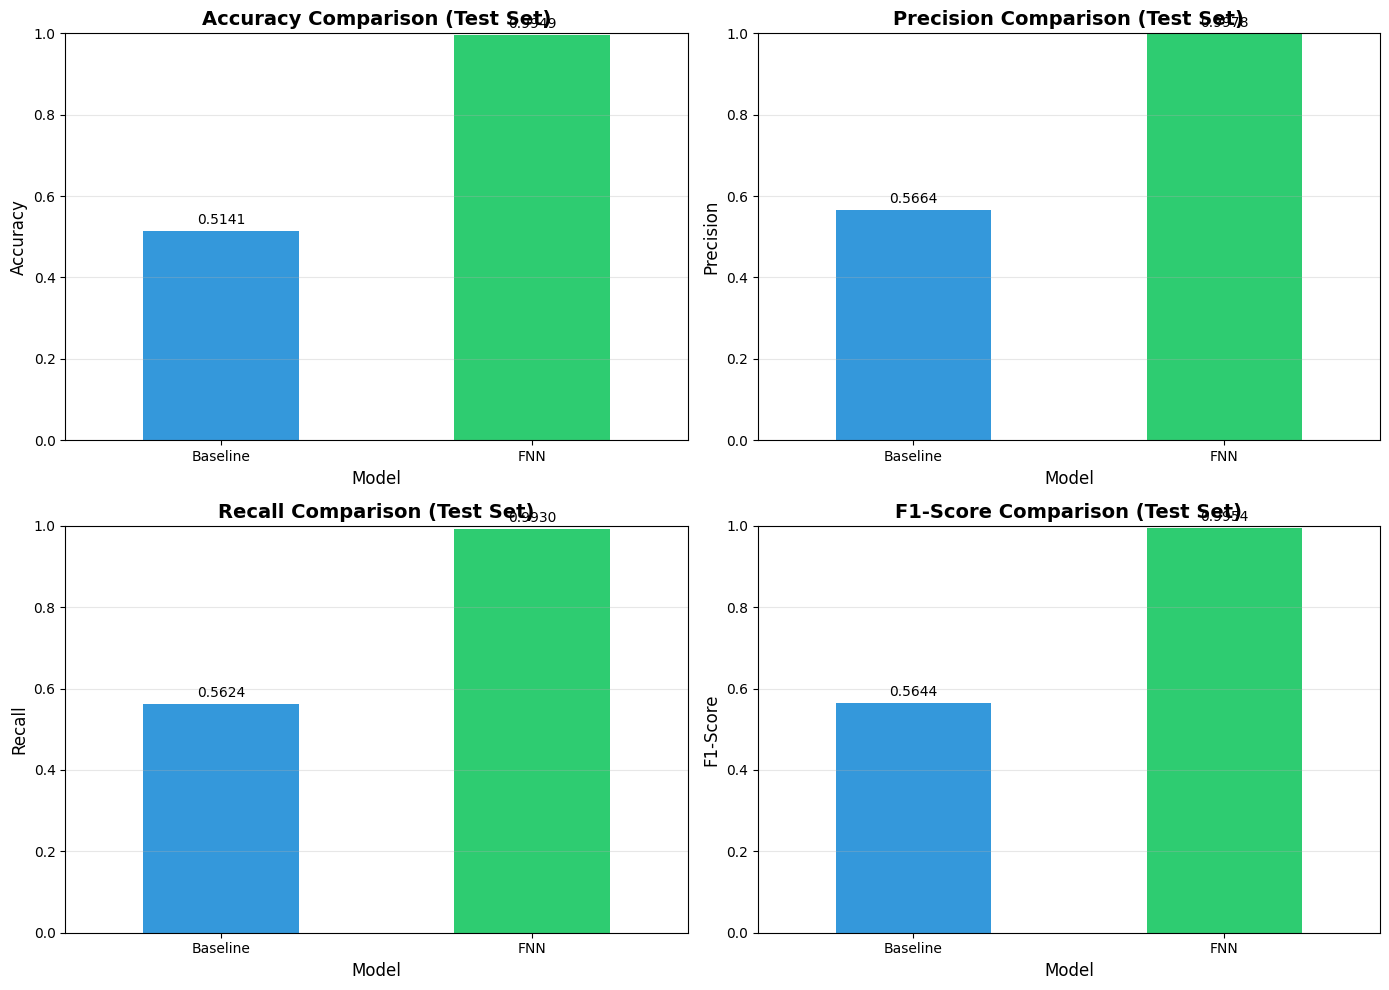


Performance Summary (Test Set):
   model dataset  accuracy  precision   recall       f1
Baseline    Test  0.514119   0.566369 0.562385 0.564370
     FNN    Test  0.994866   0.997849 0.992966 0.995402


In [17]:
# Compare model performance with bar charts
results_df = pd.DataFrame([baseline_test_results, fnn_test_results])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2

    results_df.plot(x='model', y=metric, kind='bar', ax=axes[row, col],
                    color=colors, legend=False, rot=0)
    axes[row, col].set_title(f'{title} Comparison (Test Set)', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Model', fontsize=12)
    axes[row, col].set_ylabel(title, fontsize=12)
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for container in axes[row, col].containers:
        axes[row, col].bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

print("\nPerformance Summary (Test Set):")
print(results_df.to_string(index=False))